In [12]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn -q

In [13]:
import pandas as pd
import numpy as np
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

print("All imports successful!")
print("CUDA available:", torch.cuda.is_available())

All imports successful!
CUDA available: True


In [14]:
# Load IMDB dataset
raw = load_dataset("imdb")
train_raw = pd.DataFrame(raw['train'])
test_raw  = pd.DataFrame(raw['test'])
df = pd.concat([train_raw, test_raw], ignore_index=True)

# Use a small subset for faster training (increase if you have GPU)
df = df.sample(n=3000, random_state=42).reset_index(drop=True)
print("Dataset shape:", df.shape)
print(df['label'].value_counts())

Dataset shape: (3000, 2)
label
0    1519
1    1481
Name: count, dtype: int64


In [15]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)         # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters
    text = text.lower().strip()
    return text

df['cleaned'] = df['text'].apply(clean_text)
df.dropna(inplace=True)

# Split: 80% train, 10% val, 10% test
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2400 | Val: 300 | Test: 300


In [16]:
MAX_LEN    = 64
BATCH_SIZE = 16

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = IMDBDataset(train_df['cleaned'].values, train_df['label'].values)
val_dataset   = IMDBDataset(val_df['cleaned'].values,   val_df['label'].values)
test_dataset  = IMDBDataset(test_df['cleaned'].values,  test_df['label'].values)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print("DataLoaders ready!")

DataLoaders ready!


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
)
model = model.to(device)
print("Model loaded!")

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!


In [18]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, preds, targets = 0, [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        optimizer.step()

        total_loss += outputs.loss.item()
        preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        targets.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(targets, preds)


def evaluate(model, loader):
    model.eval()
    total_loss, preds, targets = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            targets.extend(labels.cpu().numpy())
    return total_loss / len(loader), preds, targets

print("Functions defined!")

Functions defined!


In [19]:
# Reload fresh model for Experiment 1
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
EPOCHS = 2

print("=== Experiment 1: Full Fine-Tune ===")
exp1_results = []
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_loss, val_preds, val_targets = evaluate(model, val_loader)
    val_acc = accuracy_score(val_targets, val_preds)
    exp1_results.append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== Experiment 1: Full Fine-Tune ===
Epoch 1/2 | Train Loss: 0.5689 Acc: 0.7029 | Val Loss: 0.4388 Acc: 0.7900
Epoch 2/2 | Train Loss: 0.3575 Acc: 0.8550 | Val Loss: 0.4625 Acc: 0.7800


In [20]:
# Reload fresh model
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

# Freeze all BERT layers
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

print("=== Experiment 2: Frozen BERT (classifier only) ===")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
exp2_results = []
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_loss, val_preds, val_targets = evaluate(model, val_loader)
    val_acc = accuracy_score(val_targets, val_preds)
    exp2_results.append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== Experiment 2: Frozen BERT (classifier only) ===
Trainable params: 1,538
Epoch 1/2 | Train Loss: 0.7255 Acc: 0.4908 | Val Loss: 0.6976 Acc: 0.4833
Epoch 2/2 | Train Loss: 0.6963 Acc: 0.5096 | Val Loss: 0.6952 Acc: 0.4867


In [21]:
# Using the last trained model (Exp 3) — or reload whichever you want to evaluate
_, test_preds, test_targets = evaluate(model, test_loader)

print("===== Final Test Results =====")
print(f"Accuracy : {accuracy_score(test_targets, test_preds):.4f}")
print(f"Precision: {precision_score(test_targets, test_preds, average='weighted'):.4f}")
print(f"Recall   : {recall_score(test_targets, test_preds, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(test_targets, test_preds, average='weighted'):.4f}")
print("\nClassification Report:\n")
print(classification_report(test_targets, test_preds, target_names=['Negative', 'Positive']))

===== Final Test Results =====
Accuracy : 0.5133
Precision: 0.5166
Recall   : 0.5133
F1 Score : 0.5036

Classification Report:

              precision    recall  f1-score   support

    Negative       0.53      0.38      0.44       152
    Positive       0.51      0.66      0.57       148

    accuracy                           0.51       300
   macro avg       0.52      0.52      0.50       300
weighted avg       0.52      0.51      0.50       300



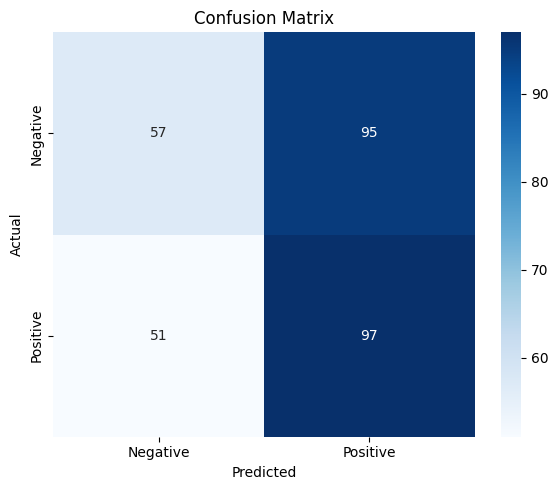

In [22]:
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [24]:
comparison = pd.DataFrame({
    'Experiment':    ['Full Fine-Tune', 'Frozen BERT'],
    'Val Acc Ep1':   [exp1_results[0], exp2_results[0]],
    'Val Acc Ep2':   [exp1_results[1], exp2_results[1]],
})
print(comparison.to_string(index=False))

    Experiment  Val Acc Ep1  Val Acc Ep2
Full Fine-Tune     0.790000     0.780000
   Frozen BERT     0.483333     0.486667
